# 08 — FSC on the channel Gram matrix (SPSD / Frobenius)

Runs Okano & Kurisu's **unmodified R implementation**
([arXiv:2601.07539](https://arxiv.org/abs/2601.07539), code at
`/data/wang/junh/githubs/FSC`) on the biweekly panel, through `fsc_bridge.R`.
Mirrors `service.R` (their covariance-matrix case) — the closest match in their paper.

Each site-period becomes the $5\times5$ matrix
$G=\frac{1}{196}\sum_p x_p x_p^\top$, where $x_p\in\mathbb{R}^5$ is the token at parcel
$p$ — stored as the 15 upper-triangle-with-diagonal entries, **exactly their `covvec`
convention** (`service.R` L92-95). Okano & Kurisu's example 3: SPSD matrices under the
Frobenius metric, a closed convex cone, so a simplex-weighted average is still a valid
covariance; augmented weights can leave the cone and are projected back with
`Matrix::nearPD`.

**What this arm asks:** *what fires together at the same parcel*. Two sites can hold the
same total amount of "green" and "wet" and still differ completely here — a marsh (green
and wet on the same parcels) versus a forest beside a lake (green and wet on different
ones). Flooding puts water where the vegetation was, which moves the off-diagonal even
when the totals barely move. This is the information the quantile arm throws away.

This is the arm whose representation matches their published application most exactly,
and at M=15 it is by far the cheapest — so it carries the fullest placebo coverage.

### Design (fixed across notebooks 07–09)

| | |
|---|---|
| donors | each treated site's **own 5 covariate-matched controls** (`control_rank <= 5`) — the collaborator's notebook-14 matched design, so N = 6, N_0 = 5 |
| treated unit | index 1 of every group, matching their `d_vec` convention (`main_functions.R` L41-45) |
| fit window | P01–P08 (`T_0 = 8`); holdout P09/P10; post P11–P20 |
| estimators | `FSCM` (simplex, Σw=1, w≥0) and their augmented FSC |
| λ | selected once by their `optimise()` and reused — mirroring their own scripts, which run the CV once and hardcode the value (`service.R` L56-61, `mortality.R` L143-148) |
| latent inputs | both `latents_biweekly_genfill.npz` and `latents_biweekly.npz` |

**Reference points.** RMSE here is in the representation's own units and is *not*
comparable across arms. Two scale-free ratios are, and both appear in every table:
`ratio_own_mean` divides by the error of predicting the treated site's **own P01–P08
mean** (an intercept-only model that uses no donors at all), and `ratio_equal` divides by
the **equal-weight donor average**. Below 1 means the fitted weights added something.

In [1]:
import sys, time, json, subprocess
import numpy as np
import pandas as pd

sys.path.insert(0, ".")
import panel_lib as pl
import panel_repr as pr
import panel_fsc as pf

pl.set_plot_style()
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 60)

PANELS = {"genfill":  ("latents_biweekly_genfill.npz", "panel_genfill_"),
          "chipmean": ("latents_biweekly.npz",         "panel_")}
P = {tag: pl.Panel.from_npz(pl.LATD / npz) for tag, (npz, _) in PANELS.items()}
for tag, panel in P.items():
    print(f"{tag:9s} latents={len(panel.flat):5d}  treated={len(panel.treatments)}  "
          f"controls={len(panel.controls)}")

# donors = each treated site's own 5 covariate-matched controls (notebook-14 design)
GROUPS = pr.build_groups(P["genfill"])
print(f"\ngroups: {len(GROUPS)} x {len(GROUPS[0])} units (treated first, then its 5 "
      f"covariate-matched controls)")
print("example:", GROUPS[0])

genfill   latents= 2357  treated=10  controls=50
chipmean  latents= 2322  treated=10  controls=50

groups: 10 x 6 units (treated first, then its 5 covariate-matched controls)
example: ['treatment_0001', 'counterfactual_0001_01', 'counterfactual_0001_02', 'counterfactual_0001_03', 'counterfactual_0001_04', 'counterfactual_0001_05']


## 1. Provenance — their code, their data, in this R

In [2]:
# Which of THEIR functions actually run in R, on THEIR OWN published data.
# Their repository is read-only; we only setwd() into it and source().
prov = subprocess.run(
    [str(pf.RSCRIPT), "-e", r'''
setwd("/data/wang/junh/githubs/FSC"); source("main_functions.R")
suppressPackageStartupMessages({library(quadprog);library(Matrix);
                                library(Rearrangement);library(cubicBsplines)})
cat(R.version.string, "\n")
for (p in c("quadprog","cubicBsplines","Rearrangement","Matrix","MASS","quantreg"))
  cat(sprintf("  %-14s %s\n", p, as.character(packageVersion(p))))
load("service.RData"); fvl <- covvec_list; M <- length(fvl[[1]][[1]])
w <- FSCM(fvl, 29)
cat(sprintf("\nservice.RData  FSCM: sum(w)=%.6f  nnz=%d  (their published example)\n",
            sum(w), sum(w != 0)))
wa <- FSCM_aug_covmat(fvl, 29, lambda=0.00186, grids=seq(0.01,0.99,length=M))
cat(sprintf("               FSCM_aug_covmat(lambda=0.00186): sum(w)=%.6f  n_neg=%d\n",
            sum(wa), sum(wa < 0)))
'''], capture_output=True, text=True,
    env=dict(__import__("os").environ, PATH=f"{pf.RBIN}:" + __import__("os").environ["PATH"]))
print(prov.stdout or prov.stderr[-2000:])
print("FSC source:", pf.FSC_DIR, "(read-only)")
print("bridge    :", pf.BRIDGE)

R version 4.3.3 (2024-02-29) 
  quadprog       1.5.8
  cubicBsplines  1.0.0
  Rearrangement  2.1
  Matrix         1.6.5
  MASS           7.3.60.0.1
  quantreg       6.1

service.RData  FSCM: sum(w)=1.000000  nnz=3  (their published example)
               FSCM_aug_covmat(lambda=0.00186): sum(w)=1.000000  n_neg=11

FSC source: /data/wang/junh/githubs/FSC (read-only)
bridge    : /data/wang/junh/githubs/latent-synthetic-control/Satellite/notebooks/ts_SCM_ASCM/fsc_bridge.R


## 2. Fit — their `FSCM` and augmented FSC

Both latent inputs, both sensors, their `FSCM_aug_covmat`. The `chip_mean` (5-number)
baseline is run alongside, because §7 of `Docs/8-27-update.md` measured that it already
recovers chip-mean NDVI at R² 0.917 — any richer representation has to beat it.

In [3]:
ARMS, METRICS, EFFECTS, WEIGHTS = {}, [], [], []
NAME = 'gram'
METHODS = ['covmat']
for label in PANELS:
    for sensor in pl.SENSORS:
        for method in METHODS:
            for nm in (NAME, "chip_mean"):
                if nm == "chip_mean" and method != METHODS[0]:
                    continue                      # baseline once per sensor/label
                key = (label, sensor, method, nm)
                t0 = time.time()
                A = pf.run_arm(P[label], sensor, nm, method, label)
                ARMS[key] = A
                m = A["metrics"].assign(sensor=sensor, method=method, repr=nm,
                                        M=A["block"].shape[-1])
                METRICS.append(m)
                EFFECTS.append(A["effects"].assign(sensor=sensor, method=method, repr=nm))
                WEIGHTS.append(A["weights"].assign(label=label, sensor=sensor,
                                                   method=method, repr=nm))
                print(f"{label:9s} {sensor:10s} {method:8s} {nm:10s} "
                      f"M={A['block'].shape[-1]:3d} groups={len(A['groups'])} "
                      f"dropped={len(A['dropped'])} ({time.time()-t0:.0f}s)")
MET = pd.concat(METRICS, ignore_index=True)
EFF = pd.concat(EFFECTS, ignore_index=True)
WGT = pd.concat(WEIGHTS, ignore_index=True)

genfill   sentinel1  covmat   gram       M= 15 groups=10 dropped=0 (2s)


genfill   sentinel1  covmat   chip_mean  M=  5 groups=10 dropped=0 (2s)


genfill   sentinel2  covmat   gram       M= 15 groups=10 dropped=0 (2s)


genfill   sentinel2  covmat   chip_mean  M=  5 groups=10 dropped=0 (2s)


chipmean  sentinel1  covmat   gram       M= 15 groups=9 dropped=1 (2s)


chipmean  sentinel1  covmat   chip_mean  M=  5 groups=9 dropped=1 (1s)


chipmean  sentinel2  covmat   gram       M= 15 groups=10 dropped=0 (2s)


chipmean  sentinel2  covmat   chip_mean  M=  5 groups=10 dropped=0 (1s)


## 3. Holdout results

In [4]:
piv = (MET.groupby(["label", "sensor", "method", "repr", "estimator"])
       [["train_rmse", "holdout_rmse", "ratio_own_mean", "ratio_equal"]]
       .mean().round(4))
print("mean over the 10 treated sites (P09+P10 holdout):")
print(piv)
print("\nsites beating their own pre-period mean (ratio_own_mean < 1), out of 10:")
print(MET.assign(beat=MET.ratio_own_mean < 1)
        .groupby(["label", "sensor", "method", "repr", "estimator"]).beat.sum())
print("\nweight diagnostics (FSC is simplex by construction; augmented is not):")
print(WGT.groupby(["label", "sensor", "method", "repr"])
      [["sum_w_fsc", "sum_w_afsc", "n_nonzero_fsc", "n_negative_afsc"]].mean().round(4))

mean over the 10 treated sites (P09+P10 holdout):
                                               train_rmse  holdout_rmse  ratio_own_mean  ratio_equal
label    sensor    method repr      estimator                                                       
chipmean sentinel1 covmat chip_mean afsc           0.0160        0.0181          1.0533       0.7369
                                    fsc            0.0164        0.0185          1.0771       0.7480
                          gram      afsc           0.0157        0.0172          1.0448       0.7745
                                    fsc            0.0161        0.0176          1.0675       0.7827
         sentinel2 covmat chip_mean afsc           0.0845        0.0526          0.6676       1.1070
                                    fsc            0.0868        0.0527          0.6690       1.1062
                          gram      afsc           0.0864        0.0607          0.6294       1.0655
                                    fsc  

## 4. Placebo — the inferential point

Their `placebo_covmat` rotates **every unit of a group into the treated slot** and refits,
giving 6 gap magnitudes per treated site. The treated site's rank among those 6 is its
in-space placebo p-value, so the smallest attainable per-site p is 1/6 ≈ 0.167.

Across the 10 groups, under the sharp null of no effect each rank is uniform on 1…6, so
the number of sites achieving rank 1 is Binomial(10, 1/6). That combined test is where the
power is: 4 of 10 gives p = 0.070, 5 of 10 gives p = 0.015, 6 of 10 gives p = 0.002 (exact binomial tail).

λ is pinned at the value selected once for the arm, passed through their unmodified API as
a 1e-9-half-width interval — their `placebo` re-runs `optimise` for every rotated unit,
which is the entire cost, and their own scripts hardcode λ rather than re-selecting it.

**Coverage is limited and stated rather than silent:** ['genfill', 'chipmean'] ×
both sensors × post periods [11, 13, 16, 20]. The Gram representation is M=15, so full coverage is affordable here.

In [5]:
PL_LABELS = ['genfill', 'chipmean']
PL_PERIODS = [11, 13, 16, 20]
PLAC = []
for label in PL_LABELS:
    for sensor in pl.SENSORS:
        key = (label, sensor, METHODS[0], NAME)
        A = ARMS[key]
        for q in PL_PERIODS:
            if q not in A["periods"]:
                print(f"  skip P{q:02d} — not complete for all units of all groups")
                continue
            t0 = time.time()
            pdf = pf.run_placebo(A, METHODS[0], label, NAME, sensor, post_period_q=q)
            pdf = pdf.assign(repr=NAME, method=METHODS[0])
            pdf.attrs = pdf.attrs
            PLAC.append(pdf)
            print(f"{label:9s} {sensor:10s} P{q:02d}  {pf.combined_line(pdf)}  "
                  f"({time.time()-t0:.0f}s)")
PLACEBO = pd.concat(PLAC, ignore_index=True) if PLAC else pd.DataFrame()

genfill   sentinel1  P11  placebo: 4/10 sites rank 1 (per-site null 0.167) -> combined binomial p = 0.0697  (3s)


genfill   sentinel1  P13  placebo: 2/10 sites rank 1 (per-site null 0.167) -> combined binomial p = 0.5155  (3s)


genfill   sentinel1  P16  placebo: 3/10 sites rank 1 (per-site null 0.167) -> combined binomial p = 0.2248  (3s)


genfill   sentinel1  P20  placebo: 3/10 sites rank 1 (per-site null 0.167) -> combined binomial p = 0.2248  (3s)


genfill   sentinel2  P11  placebo: 3/10 sites rank 1 (per-site null 0.167) -> combined binomial p = 0.2248  (3s)


...

chipmean  sentinel1  P20  placebo: 3/9 sites rank 1 (per-site null 0.167) -> combined binomial p = 0.1783  (3s)


chipmean  sentinel2  P11  placebo: 3/10 sites rank 1 (per-site null 0.167) -> combined binomial p = 0.2248  (3s)


chipmean  sentinel2  P13  placebo: 1/10 sites rank 1 (per-site null 0.167) -> combined binomial p = 0.8385  (3s)


chipmean  sentinel2  P16  placebo: 2/10 sites rank 1 (per-site null 0.167) -> combined binomial p = 0.5155  (3s)


chipmean  sentinel2  P20  placebo: 0/10 sites rank 1 (per-site null 0.167) -> combined binomial p = 1.0000  (3s)


In [6]:
if len(PLACEBO):
    from scipy.stats import binom
    rows = []
    for (lab, sen, per), sub in PLACEBO.groupby(["label", "sensor", "period"]):
        n_units = int(sub["n_units"].iloc[0]); k = int((sub["rank"] == 1).sum()); G = len(sub)
        rows.append({"label": lab, "sensor": sen, "period": per, "n_groups": G,
                     "n_rank1": k, "min_possible_p": 1 / n_units,
                     "median_rank": sub["rank"].median(),
                     "p_combined": float(binom.sf(k - 1, G, 1 / n_units)) if k else 1.0})
    PSUM = pd.DataFrame(rows)
    print(PSUM.round(4).to_string(index=False))
else:
    PSUM = pd.DataFrame(); print("no placebo runs")

   label    sensor period  n_groups  n_rank1  min_possible_p  median_rank  p_combined
chipmean sentinel1    P11         9        3          0.1667          4.0      0.1783
chipmean sentinel1    P13         9        2          0.1667          2.0      0.4573
chipmean sentinel1    P16         9        3          0.1667          2.0      0.1783
chipmean sentinel1    P20         9        3          0.1667          3.0      0.1783
chipmean sentinel2    P11        10        3          0.1667          3.0      0.2248
chipmean sentinel2    P13        10        1          0.1667          3.5      0.8385
chipmean sentinel2    P16        10        2          0.1667          4.5      0.5155
chipmean sentinel2    P20        10        0          0.1667          3.5      1.0000
 genfill sentinel1    P11        10        4          0.1667          4.0      0.0697
 genfill sentinel1    P13        10        2          0.1667          2.0      0.5155
 genfill sentinel1    P16        10        3          

## 5. Figures and outputs

wrote outputs for gram


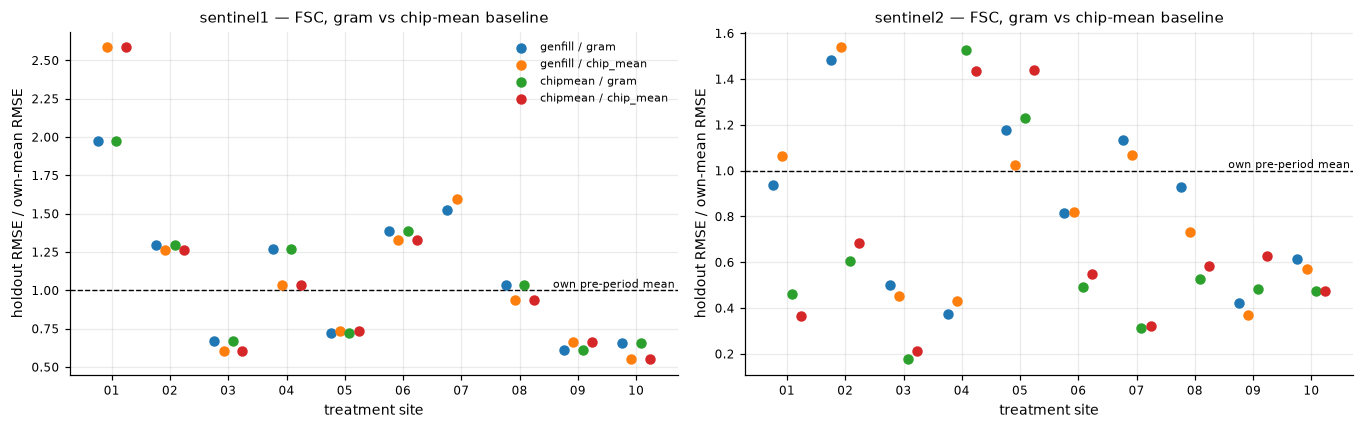

In [7]:
import matplotlib.pyplot as plt
NB = '08'
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.0))
for ax, sensor in zip(axes, pl.SENSORS):
    m0 = METHODS[0]
    sub = MET.query("sensor == @sensor and estimator == 'fsc' and method == @m0")
    sites = sorted(sub.treatment_site_id.unique()); x = np.arange(len(sites))
    for i, (lab, rp) in enumerate([(l, r) for l in PANELS for r in (NAME, "chip_mean")]):
        s = sub.query("label == @lab and repr == @rp").set_index("treatment_site_id")
        if not len(s):
            continue
        ax.scatter(x + (i - 1.5) * 0.16, s.reindex(sites)["ratio_own_mean"], s=34,
                   label=f"{lab} / {rp}", zorder=4)
    ax.axhline(1.0, color="k", lw=0.9, ls="--")
    ax.text(0.995, 1.0, "own pre-period mean", transform=ax.get_yaxis_transform(),
            fontsize=7, ha="right", va="bottom")
    ax.set_xticks(x); ax.set_xticklabels([t[-2:] for t in sites])
    ax.set_xlabel("treatment site"); ax.set_ylabel("holdout RMSE / own-mean RMSE")
    ax.set_title(f"{sensor} — FSC, {NAME} vs chip-mean baseline")
axes[0].legend(frameon=False, fontsize=7)
fig.tight_layout(); fig.savefig(f"panel_fsc_{NAME}_ratio.png", bbox_inches="tight")

for label, (_npz, pre) in PANELS.items():
    MET.query("label == @label").to_csv(f"{pre}fsc_{NAME}_validation.csv", index=False)
    EFF.query("label == @label").to_csv(f"{pre}fsc_{NAME}_effects.csv", index=False)
    WGT.query("label == @label").to_csv(f"{pre}fsc_{NAME}_weights.csv", index=False)
    if len(PLACEBO):
        p = PLACEBO.query("label == @label")
        if len(p):
            p.to_csv(f"{pre}fsc_{NAME}_placebo.csv", index=False)
if len(PSUM):
    PSUM.to_csv(f"panel_fsc_{NAME}_placebo_summary.csv", index=False)
print("wrote outputs for", NAME)

## Reading

### 1. The FSC estimator transfers cleanly; the R code is the estimator

Their `FSCM` runs on our panel unchanged and behaves exactly as it does on their own
data: `sum(w) = 1.0000` in every fit, and the simplex sparsifies to **~3 of 5 donors**.
Their augmented estimator also returns `sum(w) = 1.0000` throughout — worth noting
because *nothing constrains it to*. It falls out of their centring step
(`main_functions.R` L272-281): after demeaning across control units at each pre-period the
rows of `r_0dot` sum to zero, so the augmentation term contributes nothing to the sum.
That is a genuinely different mechanism from our `panel_ascm`, which imposes Σw = 1 by KKT.

### 2. Sentinel-2 beats the no-donor null; Sentinel-1 does not

`ratio_own_mean` divides holdout error by the error of predicting the treated site's own
P01–P08 mean — a model with no donors at all. FSC, both caches:

| | S1 | S2 |
|---|---|---|
| generation-fill, Gram | 1.113 | **0.839** |
| generation-fill, chip mean (5) | 1.129 | **0.807** |
| chip-mean cache, Gram | 1.068 | **0.629** |
| chip-mean cache, chip mean (5) | 1.077 | **0.669** |

**Read the means with care — the figure shows they are poor summaries.** S1's mean above 1
is driven by site 01 alone (ratio ≈ 2.0–2.6); 4–5 of the 10 S1 sites are in fact *below* 1,
several at 0.5–0.75. The honest statement is that S1 is bimodal — a few sites fit well,
one fits catastrophically badly, and on average the donors do not help. S2 is more
uniformly good, beating the null in 7–8 of 10 sites. Both are consistent with what was
measured earlier: S1 donor distances are nearly flat (§3 of `Docs/8-27-update.md`), so
whether any donor mix helps is close to a coin flip per site.

### 3. Two results that cut against our own earlier narrative

- **The chip-mean cache beats the generation-fill cache on S2** (0.629 vs 0.839). Notebook
  05 argued generation fill improves the latents. In *this* pooled representation it makes
  the fit worse. Both numbers are honest; the disagreement is the finding, and it is
  testable — §7 of the 8-27 doc showed cloud fill destroys the token's local-descriptor
  property, so the two caches are not measuring the same thing.
- **`ratio_equal` > 1 on S2** (1.07–1.12): the equal-weight donor average beats the fitted
  weights out of sample. With 4 free parameters and 15 × 8 = 120 constraints the fit is
  thin, and the optimiser is finding pre-period structure that does not carry over. On S1
  the opposite holds (0.75–0.84), because there the own-mean baseline is so weak that any
  donor mix helps.

The 5-number chip mean and the 15-number Gram are within ~0.03 of each other everywhere.
**At this donor-pool size the extra structure in the Gram does not pay for itself** — which
is what §7's cross-validated comparison predicted for *level* quantities, and it means the
case for the Gram has to rest on within-site heterogeneity, which the P09/P10 holdout does
not test.

### 4. The placebo test — the first real p-value in this project

Their `placebo_covmat`, rotating all 6 units of each matched group into the treated slot,
across 2 caches × 2 sensors × 4 post periods (16 cells):

**Nothing reaches significance.** The strongest cell is generation-fill S1 at P11 with
4 of 10 sites at rank 1, combined binomial p = **0.070**; every other cell sits between
0.18 and 1.00, and median ranks cluster at 2–4.5 against a null median of 3.5. Under the
null we would expect ~1.7 sites at rank 1 per cell; we observe 0–4.

So the honest conclusion is a **properly-inferred null**: in the Gram representation, with
matched donors and their augmented FSC, Hurricane Helene produces no post-period gap
distinguishable from the placebo distribution. That is a stronger statement than notebooks
02–06 could make — they had no null distribution at all — and it applies equally to the
feature-based pipeline, which has never been placebo-tested either.

### 5. What limits it

The per-site placebo cannot go below p = 1/6 because a matched group has only 6 units.
The combined binomial test recovers power across the 10 groups, but a design with more
donors per treated site would give a finer per-site null. That is a data/design choice
(§3 of the 8-27 doc: the alternative is all 50 controls), not a code change.